In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import fftpack

In [21]:
# matplotlib parameters 
large = 40; med = 20; small = 20
params = {'axes.titlesize': med,'axes.titlepad' : med,
          'legend.fontsize': med,'axes.labelsize': med ,
          'axes.titlesize': med ,'xtick.labelsize': med ,
          'ytick.labelsize': med ,'figure.titlesize': med}
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["font.serif"] = ["Helvetica Neue"]          
#plt.rcParams['text.usetex'] = True # need LaTeX. Change it to False if LaTeX is not installed in the system
plt.rcParams.update(params)

In [22]:
h_bar = 1.0545718*10**(-34)
# Trap parameters.
trap_frequency = 2*np.pi*1000 # Hz
# Rb87 parameters.
atom_mass = 1.4192261*10**(-25) # kg
a_s = 98.006*5.29*10**(-11) # m https://journals.aps.org/pra/abstract/10.1103/PhysRevA.87.053614

# Dimensionless parameters.
a_0 = np.sqrt(h_bar/(trap_frequency*atom_mass)) # m
g = 4*np.pi*h_bar**2*a_s/(np.pi*a_0**2*atom_mass)

In [23]:
def GrossPitaevskiiSolver(dt, tmax, position_arr, potential_func, number_of_atoms, initial_wavefunction):

     if 4*np.pi*a_s*number_of_atoms < a_0:
          print(4*np.pi*a_s*number_of_atoms,"must be greater than ", a_0)

     number_density = number_of_atoms/(np.pi*a_0**2*(np.ptp(position_arr)))
     if number_density *a_s**3 > 1:
          # Ref: Rev. Mod. Phys. 71, 463 (1999)
          print("Gross-Pitaevskii equation is valid if:", number_density*a_s**3 ,"<< 1")


     dx = position_arr[1] - position_arr[0]
     N = len(position_arr)

     x_s = (4*np.pi*a_s*number_of_atoms*a_0**4)**(1/5)
     epsilon = (h_bar/(atom_mass*trap_frequency*x_s**2))
     delta = (g*number_of_atoms*(x_s**2))/(a_0**3*h_bar*trap_frequency)
     position_arr_dimless = position_arr/x_s
     dx_dimless = dx/x_s
     L_dimless  = np.ptp(position_arr_dimless)
     dk_dimless = (2*np.pi)/L_dimless
     dt_dimless = dt*trap_frequency
     tmax_dimless = tmax*trap_frequency

     # Normalize the wavefunction.
     def normalize(psi_dimless):
          return psi_dimless/np.sqrt(np.sum(psi_dimless**2)*dx_dimless)
     def normalize_k(psi_dimless):
          return psi_dimless/np.sqrt(np.sum(psi_dimless**2)*dk_dimless)
          
     if initial_wavefunction is None:
          print("Initial wavefunction is not provided. Using a Gaussian wavefunction as the initial wavefunction.")
          amplitude = 1.0
          mean = np.mean(position_arr_dimless)
          std_dev = 0.1
          psi_initial_dimless = amplitude * np.exp(-(position_arr_dimless - mean)**2 / (2 * std_dev**2))*np.sqrt(x_s)
          psi_initial_dimless = normalize(psi_initial_dimless)
     else:
          psi_initial_dimless = normalize(initial_wavefunction)   
          print("Initial wavefunction is normalized = ", np.sum(np.abs(psi_initial_dimless)**2)*dx_dimless) 
          
     def hamiltonian_x_dimless(potential_func, psi_x_dimless):
          return potential_func/(epsilon*atom_mass*trap_frequency**2*x_s**2)+delta*epsilon**(3/2)*np.abs(psi_x_dimless)**2

     def kinetic_energy_dimless(N):
          k_dimless = np.hstack([np.arange(0,N/2), np.arange(-N/2,0)])*dk_dimless
          if len(k_dimless) != N:
               k_dimless = np.hstack([np.arange(0,N/2), np.arange(-N/2+1,0)])*dk_dimless     
          return k_dimless**2*epsilon/2  

     total_iterations = int(np.abs(tmax_dimless)/np.abs(dt_dimless))
     print('Total iterations: ', total_iterations)
     psi_x_dimless = psi_initial_dimless

     for _ in range(total_iterations):

          psi_x_dimless = np.exp(-hamiltonian_x_dimless(potential_func, psi_x_dimless) * 1j*dt_dimless/2) * psi_x_dimless

          psi_k_dimless = fftpack.fft(psi_x_dimless)        
          psi_k_dimless = np.exp(-(kinetic_energy_dimless(N) * 1j*dt_dimless)) * psi_k_dimless

          psi_x_dimless = fftpack.ifft(psi_k_dimless)
          psi_x_dimless = normalize(psi_x_dimless)
          psi_x_dimless = np.exp(-hamiltonian_x_dimless(potential_func, psi_x_dimless) * 1j*dt_dimless/2) * psi_x_dimless
          
     print("Normalization of the final wavefunction: ", np.sum(np.abs(psi_x_dimless)**2)*dx_dimless)

     return psi_x_dimless

# Potential Well

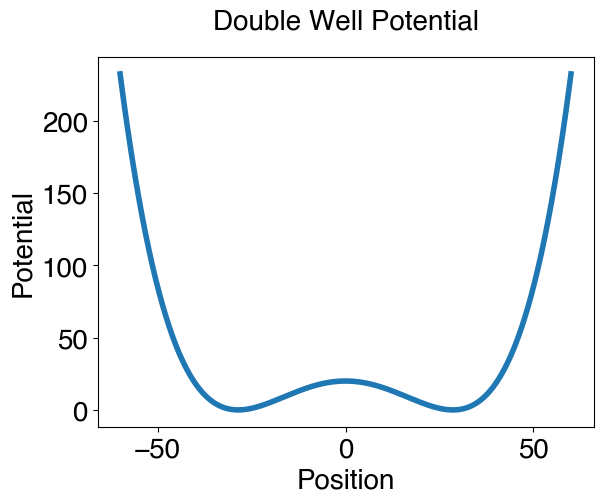

In [24]:
def double_well_potential(x, a, barrier_height):
    """
    Constructs a double well potential.
    
    Parameters:
    x (ndarray): Array of positions where the potential is evaluated.
    a (float): Parameter controlling the depth of the wells.
    b (float): Parameter controlling the separation and height of the barrier.
    
    Returns:
    V (ndarray): Array of potential values corresponding to positions x.
    """
    b = (barrier_height/a)**(1/4)

    V = a * (x**2 - b**2)**2
    return V # in kHz.

# Example usage
double_well_position = np.linspace(-60.0, 60.0, 2**12) # in micrometers.
double_well_potential = double_well_potential(double_well_position, 3.e-5, 20)

# Plotting the potential
plt.plot(double_well_position, double_well_potential, linewidth=4)
plt.xlabel('Position')
plt.ylabel('Potential')
plt.title('Double Well Potential')
#plt.grid(True)
plt.show()

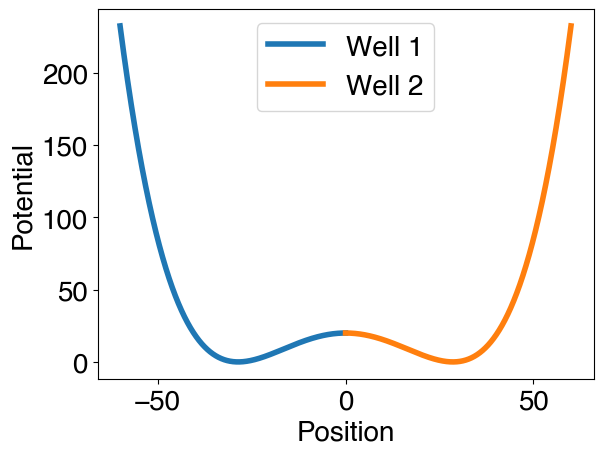

In [25]:
# Here will separate the potential into two wells.
left_well_position = double_well_position[double_well_position <= 0]
left_well_potential = double_well_potential[double_well_position <= 0]
right_well_position = double_well_position[double_well_position >= 0]
right_well_potential = double_well_potential[double_well_position >= 0]
plt.plot(left_well_position, left_well_potential , linewidth=4, label="Well 1")
plt.plot(right_well_position, right_well_potential, linewidth=4, label="Well 2")
plt.legend()
plt.xlabel('Position')
plt.ylabel('Potential')
plt.show()

# Left Well

In [26]:
# Parameters
dt = -1j*10**(-7) # In seconds unit.
tmax = 1.e-2 # In seconds unit.
N_atom_left = 1000 # Total number of atoms

# Solve the Gross-Pitaevskii equation.
left_well_ground_state = GrossPitaevskiiSolver(dt, tmax, left_well_position*1.e-6, left_well_potential*10**3*h_bar*2*np.pi, N_atom_left, None)

Initial wavefunction is not provided. Using a Gaussian wavefunction as the initial wavefunction.
Total iterations:  100000
Normalization of the final wavefunction:  0.9982111695637853


In [27]:
# Parameters
dt = -1j*10**(-8) # In seconds unit.
tmax = 1.e-3 # In seconds unit.
N_atom_right = 4000 # Total number of atoms

# Solve the Gross-Pitaevskii equation.
right_well_ground_state = GrossPitaevskiiSolver(dt, tmax, right_well_position*1.e-6, right_well_potential*10**3*h_bar*2*np.pi, N_atom_right, None)

Initial wavefunction is not provided. Using a Gaussian wavefunction as the initial wavefunction.
Total iterations:  100000
Normalization of the final wavefunction:  3.196847624815242


# Real Time Evolution

In [ ]:
# Concate the two wavefunctions.
psi_two_wells_initial = np.hstack([left_well_ground_state, right_well_ground_state])

# Construct the double well potential.
two_wells_position = np.hstack([left_well_position, right_well_position])
two_wells_potential = np.hstack([left_well_potential, right_well_potential])

# Real time evolution of the wavefunction.
# Parameters
dt = 10**(-6) # In seconds unit.
tmax = 10*1.e-3 # In seconds unit.
N_atom = N_atom_left + N_atom_right # Total number of atoms

# Solve the Gross-Pitaevskii equation.
real_time_evolution_wavefunction = GrossPitaevskiiSolver(dt, tmax, two_wells_position*1.e-6, two_wells_potential*10**3*h_bar*2*np.pi, N_atom, psi_two_wells_initial)

In [ ]:
len(two_wells_potential)

In [ ]:
# Plotting the two potential wells and two wavefunctions together in the same plot.
fig, ax1 = plt.subplots()
fig.set_size_inches(10, 6)
ax2 = ax1.twinx()
ax1.plot(double_well_position, double_well_potential, "tab:orange", linewidth=4, label="Potential well")
ax2.plot(double_well_position, np.abs(psi_two_wells_initial)**2, "tab:red", linewidth=4, label="Wavefunction")
ax1.set_xlabel('Position')
ax1.set_ylabel('Potential')

ax2.set_ylabel('Wavefunction')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

In [ ]:
# Plotting the wavefunction and the potential.
fig, ax1 = plt.subplots()
fig.set_size_inches(10, 6)
ax2 = ax1.twinx()
ax1.plot(double_well_position, double_well_potential, "tab:orange", linewidth=4, label="Double well potential")
ax2.plot(double_well_position, np.abs(real_time_evolution_wavefunction)**2, "tab:green", linewidth=4, label="Wavefunction")
ax1.set_xlabel('Position')
ax1.set_ylabel('Potential')

ax2.set_ylabel('Wavefunction')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()
